In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

df = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])

# Reference date (last date in dataset + 1 day)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM calculation - FIXED COLUMN NAMES
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency (using 'Invoice' instead of 'InvoiceNo')
    'TotalPrice': 'sum'  # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
})

print(rfm.head())
print(f"\nRFM Stats:")
print(rfm.describe())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          529         10    327.86
12347.0            2          8   4371.34
12348.0           75          5    573.24
12349.0           19          3   2843.99
12350.0          310          1    334.40

RFM Stats:
           Recency    Frequency       Monetary
count  5680.000000  5680.000000    5680.000000
mean    200.941021     5.859507    1550.081940
std     208.685843    11.526613    3692.387326
min       1.000000     1.000000       0.000000
25%      26.000000     1.000000     264.767500
50%      95.000000     3.000000     659.890000
75%     380.000000     6.000000    1635.670000
max     739.000000   365.000000  178266.580000


In [3]:
for col in ['Recency', 'Frequency', 'Monetary']:
    cap = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=cap)


In [5]:
rfm = rfm.replace([np.inf, -np.inf], np.nan)
rfm = rfm.dropna()

print(f"After cleaning: {rfm.shape} customers")


After cleaning: (5680, 3) customers


In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

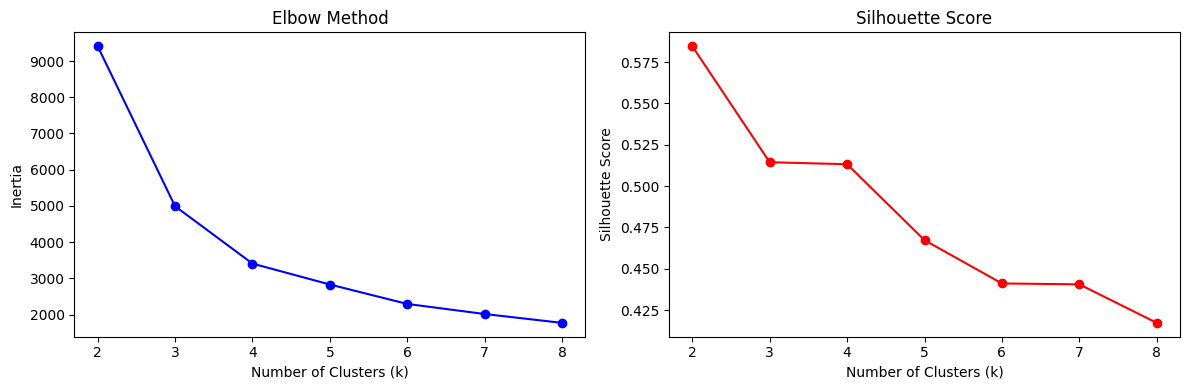

In [9]:
inertias = []
silhouette_scores = []
K_range = range(2, 9)  # Reduced range for faster computation

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot elbow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

In [10]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)


In [12]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_summary['Customer Count'] = rfm.groupby('Segment').size()
segment_summary = segment_summary.sort_values('Monetary', ascending=False)

# Add descriptive names
segment_names = {
    segment_summary.index[0]: 'Champions',
    segment_summary.index[1]: 'Loyal Customers',
    segment_summary.index[2]: 'Potential Loyalists',
    segment_summary.index[3]: 'New Customers',
    segment_summary.index[4]: 'At Risk',
    segment_summary.index[5]: 'Lost Customers'
}
segment_summary['Segment Name'] = segment_summary.index.map(segment_names)

print("\n" + "="*60)
print("SEGMENT SUMMARY")
print("="*60)
print(segment_summary)



SEGMENT SUMMARY
         Recency  Frequency  Monetary  Customer Count         Segment Name
Segment                                                                   
3          26.66      33.91   9870.57             157            Champions
4          36.86      17.42   5346.36             379      Loyal Customers
0          55.63       9.07   2409.28             934  Potential Loyalists
1          68.12       2.97    644.58            2121        New Customers
5         360.02       2.37    558.95            1367              At Risk
2         601.31       1.51    310.52             722       Lost Customers


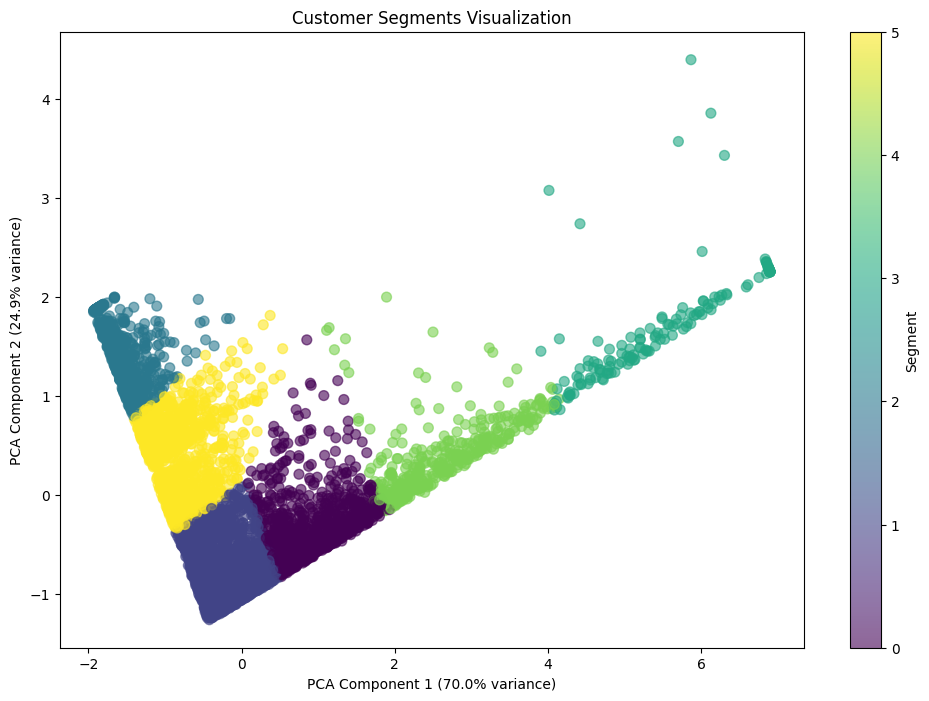

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], 
                       c=rfm['Segment'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Segment')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Segments Visualization')
plt.savefig('../data/processed/segment_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
import os
import joblib

In [18]:
os.makedirs('../src/models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(kmeans, '../src/models/kmeans_segmenter.pkl')
joblib.dump(scaler, '../src/models/rfm_scaler.pkl')
rfm.to_csv('../data/processed/customer_segments.csv')

print("\nSegmentation complete!")
print(f"Models saved to: ../src/models/")
print(f"Data saved to: ../data/processed/customer_segments.csv")


Segmentation complete!
Models saved to: ../src/models/
Data saved to: ../data/processed/customer_segments.csv


In [19]:
print("\n" + "="*60)
print("SEGMENT DISTRIBUTION")
print("="*60)
segment_dist = rfm['Segment'].value_counts().sort_index()
for seg in segment_dist.index:
    seg_name = segment_summary.loc[seg, 'Segment Name']
    print(f"Segment {seg} ({seg_name}): {segment_dist[seg]:,} customers ({segment_dist[seg]/len(rfm)*100:.1f}%)")


SEGMENT DISTRIBUTION
Segment 0 (Potential Loyalists): 934 customers (16.4%)
Segment 1 (New Customers): 2,121 customers (37.3%)
Segment 2 (Lost Customers): 722 customers (12.7%)
Segment 3 (Champions): 157 customers (2.8%)
Segment 4 (Loyal Customers): 379 customers (6.7%)
Segment 5 (At Risk): 1,367 customers (24.1%)


In [20]:
print("\n" + "="*60)
print("SAMPLE CUSTOMERS BY SEGMENT")
print("="*60)
for seg in range(optimal_k):
    print(f"\nSegment {seg} - {segment_summary.loc[seg, 'Segment Name']}:")
    sample = rfm[rfm['Segment'] == seg].head(3)
    print(sample[['Recency', 'Frequency', 'Monetary']])


SAMPLE CUSTOMERS BY SEGMENT

Segment 0 - Potential Loyalists:
             Recency  Frequency  Monetary
Customer ID                              
12347.0          2.0          8   4371.34
12349.0         19.0          3   2843.99
12352.0         36.0          9   1849.54

Segment 1 - New Customers:
             Recency  Frequency  Monetary
Customer ID                              
12348.0         75.0          5    573.24
12353.0        204.0          2    406.76
12358.0          2.0          5    975.97

Segment 2 - Lost Customers:
             Recency  Frequency  Monetary
Customer ID                              
12346.0        529.0         10    327.86
12368.0        628.0          1    198.40
12392.0        591.0          1     93.15

Segment 3 - Champions:
             Recency  Frequency    Monetary
Customer ID                                
12437.0          2.0         38   9999.7300
12471.0          2.0         41  12007.5701
12472.0         32.0         19  12007.5701

Segme